# Исследовательский и статистический анализ данных сервиса Яндекс Афиша
- Автор: Куколкина Алена
- Дата: 15.04.2026

## Цели и задачи проекта

В ноябре 2024 года сервис Яндекс Афиша зафиксировал аномальную динамику в структуре продаж билетов на фоне приближающегося высокого зимнего сезона. Отмечается непрогнозируемый рост конверсии по одним категориям мероприятий при одновременном падении спроса на другие. В условиях отсутствия системных данных о причинах отклонений (сезонный сдвиг предпочтений, изменение профиля аудитории или эффективности конкретных организаторов) продуктовые гипотезы не подкреплены доказательной базой. Это создает риск неоптимального распределения ресурсов при планировании новогодних акций и распродаж.

Цель настоящего исследования — с помощью детального анализа данных о посещениях, покупках и поведении пользователей на разных устройствах найти ответы на эти вопросы. Мы определим, какие события и организаторы показывают наилучшие результаты, выявим факторы роста и спада интереса аудитории, а также подготовим четкие рекомендации для эффективной подготовки сервиса к пиковому сезону новогодних продаж.

В данном проекте используем датасет, в котором содержатся данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. 

Цель проекта - изучить данные датасетов `final_tickets_orders_df.csv` и `final_tickets_events_df.csv`, провести исследовательский анализ данных, проанализировать результаты A/B-тестирования и проверить гипотезы о разнице в поведении пользователей с мобильных и стационарных устройств. Для этого необходимо выполнить следующие задачи: 
- ознакомиться с данными, 
- проконтролировать их корректность, 
- проверить наличие пропусков и дубликатов, 
- провести исследовательский анализ данных и сопроводить его подходящими визуализациями, 
- проконтролировать корректность проведения А/В-теста, 
- проверить гипотезы, 
- произвести интерпретацию результатов.

## Описание данных

Файл `final_tickets_orders_df.csv` содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 

`order_id` — уникальный идентификатор заказа;

`user_id` — уникальный идентификатор пользователя;

`created_dt_msk` — дата создания заказа (московское время);

`created_ts_msk` — дата и время создания заказа (московское время);

`event_id` — идентификатор мероприятия из таблицы events;

`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';

`age_limit` — возрастное ограничение мероприятия;

`currency_code` — валюта оплаты, например rub для российских рублей;

`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных;

`revenue` — выручка от заказа;

`service_name` — название билетного оператора;

`tickets_count` — количество купленных билетов;

`total` — общая сумма заказа;

`days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. 

Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.

`event_id` — уникальный идентификатор мероприятия;

`event_name` — название мероприятия; 

`event_type_description` — описание типа мероприятия;

`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее;

`organizers` — организаторы мероприятия;

`region_name` — название региона;

`city_name` — название города;

`venue_id` — уникальный идентификатор площадки;

`venue_name` — название площадки;

`venue_address` — адрес площадки.

Кроме того, в ходе выполнения проекта для конвертации валюты будет необходим файл `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год.

`nominal` — номинал (100 тенге);

`data` — дата;

`curs` — курс тенге к рублю;

`cdx` — обозначение валюты (kzt).

## Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общие выводы и рекомендации

##  Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки

# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Статистические тесты
from scipy.stats import levene, ttest_ind

In [2]:
# Выгружаем данные
orders_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv")
events_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_events_df.csv")

In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [5]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [6]:
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


Датасет 'final_tickets_orders_df.csv' содержит 14 столбцов и 290849 строк, в которых представлена информация о заказах билетов. Семь стобцов имеют тип данных object, три столбца - тип данных float64 и четыре столбца - тип данных int64. Один столбец из 14 содержит пропуски. Названия столбцов соответствуют содержащимся в них данным. У столбцов 'created_dt_msk' и 'created_ts_msk' следует изменить тип данных на datetime64. Текстовые и числовые данные представлены корректными типами данных, однако у числовых типов следует понизить разрядность.

Датасет 'final_tickets_events_df.csv' содержит 11 столбцов и 22427 строк, в которых представлена информация о событиях. Восемь стобцов имеют тип данных object и три столбца - тип данных int64. В данных нет пропусков, названия столбцов соответствуют содержащимся в них данным. Текстовые и числовые данные представлены корректными типами данных.

По результатам проверки корректности загруженных данных составлен следующий план по предобработке данных:

1. Анализ пропусков (проверка, что пропуски действительно имеются только у первых заказов);
2. Работа с полными и неполными дубликатами;
3. Проверка категориальных столбцов на предмет неявных дубликатов, возникающих из-за разного регистра, неединого формата записи или опечаток;
4. Проверка числовых данных на наличие невалидных значений и явных аномалий;
5. Смена типов данных на более оптимальные, чтобы уменьшить объем занимаемой памяти.
6. Приведение выручки к общей валюте (российскому рублю) для корректного анализа;

##  Предобработка данных

### Работа с дубликатами

In [7]:
# Проверим количество явных дубликатов
print(f"Количество явных дубликатов в датафрейме с заказами: {orders_df.duplicated().sum()}.")
print(f"Количество явных дубликатов в датафрейме с событиями: {events_df.duplicated().sum()}.")

Количество явных дубликатов в датафрейме с заказами: 0.
Количество явных дубликатов в датафрейме с событиями: 0.


In [8]:
# Проверим количество неявных дубликатов
orders_df.duplicated(
    subset=[
        "user_id",
        "created_ts_msk",
        "event_id",
        "device_type_canonical",
        "revenue",
        "service_name",
        "tickets_count",
    ]
).sum()

40

In [9]:
# Удаляем дубликаты
orders_df = orders_df.drop_duplicates(
    subset=[
        "user_id",
        "created_ts_msk",
        "event_id",
        "device_type_canonical",
        "revenue",
        "service_name",
        "tickets_count",
    ]
).copy()

In [10]:
len(orders_df)

290809

При поиске явных дубликатов не найдено. Поиск неявных дубликатов производился одновременно по идентификатору пользователя, дате заказа, идентификатору события, типу устройства, выручке, имени билетного оператора и количеству билетов в заказе. Удалено 40 неявных дубликатов, в датафрейме orders_df осталось 290809 строк.

### Объединение датафреймов

In [11]:
# Объединяем датафреймы
df = orders_df.merge(events_df, how='left', on='event_id')

In [12]:
# Проверим данные после объединения
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290809 entries, 0 to 290808
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290809 non-null  int64  
 1   user_id                 290809 non-null  object 
 2   created_dt_msk          290809 non-null  object 
 3   created_ts_msk          290809 non-null  object 
 4   event_id                290809 non-null  int64  
 5   cinema_circuit          290809 non-null  object 
 6   age_limit               290809 non-null  int64  
 7   currency_code           290809 non-null  object 
 8   device_type_canonical   290809 non-null  object 
 9   revenue                 290809 non-null  float64
 10  service_name            290809 non-null  object 
 11  tickets_count           290809 non-null  int64  
 12  total                   290809 non-null  float64
 13  days_since_prev         268869 non-null  float64
 14  event_name          

### Проверка пропусков

In [13]:
# Посчитаем количество пропусков из датасета final_tickets_events_df.csv
empty_events = df[df["event_name"].isna()]["event_id"].count()
empty_events_share = (
    df[df["event_name"].isna()]["event_id"].count() / df["event_id"].count() * 100
)
print(
    f"Количество пропусков из датасета с событиями равно {empty_events}, "
    f"что составляет {round(empty_events_share,2)}% от общего числа."
)

Количество пропусков из датасета с событиями равно 238, что составляет 0.08% от общего числа.


In [14]:
# Определяем общее количество пропусков в столбце "days_since_prev"
df['days_since_prev'].isna().sum()

21940

In [15]:
# Определяем количество пропусков в строках с первыми заказами пользователей
first_order_mask = (
    df.groupby("user_id")["created_ts_msk"].transform("min")
    == df["created_ts_msk"]
)
df.loc[first_order_mask, "days_since_prev"].isna().sum()

18487

При объединении датафреймов обнаружено, что для 238 заказов отсутствует информация о событиях в датасете final_tickets_events_df.csv. Принимаем решение оставить эти строки, так как информация о заказах имеет более высокий приоритет.

В 18487 строках из 21940 пропуски в столбце days_since_prev (с количеством дней с предыдущей покупки для каждого пользователя) действительно возникли в данных с первыми заказами, что ожидаемо. 3453 строки имеют пропуски по другой причине. 

### Проверка категориальных столбцов

In [16]:
# Проверяем уникальные значения в категориальных столбцах
for column in [
    "cinema_circuit",
    "age_limit",
    "currency_code",
    "device_type_canonical",
    "event_type_main",
]:
    print(df[column].sort_values().unique())

['Другое' 'КиноСити' 'Киномакс' 'Москино' 'ЦентрФильм' 'нет']
[ 0  6 12 16 18]
['kzt' 'rub']
['desktop' 'mobile']
['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки' nan]


In [17]:
# Проверка редких значений в названиях регионов и билетных операторов
print("Самые редкие значения в 'region_name':")
print(df['region_name'].value_counts().tail(10), '\n')

print("Самые редкие значения в 'service_name':")
print(df['service_name'].value_counts().tail(10), '\n')

Самые редкие значения в 'region_name':
Тихогорская область         48
Кристальная область         35
Островогорский округ        31
Светолесский край           24
Яснопольский округ          21
Лесноярский край            19
Крутоводский регион         18
Верхозёрский край           11
Сосноводолинская область    10
Теплоозёрский округ          7
Name: region_name, dtype: int64 

Самые редкие значения в 'service_name':
Реестр                125
Билет по телефону      85
Вперёд!                80
Дырокол                74
Кино билет             67
Цвет и билет           61
Тех билет              22
Лимоны                  8
Зе Бест!                5
Билеты в интернете      4
Name: service_name, dtype: int64 



В категориальных значениях дубликатов не найдено. В названиях регионов и билетных операторов выделены самые редкие варианты, однако опечаток и отличий от основного формата записи не найдено.

#### Проверка значений по полю 'revenue'

In [33]:
# Проверим статистические показатели по полю 'revenue' для валюты 'рубли'
df[df['currency_code']=='rub']['revenue'].describe()

count    282884.000000
mean        509.982056
std         500.109406
min         -90.760002
25%         111.680000
50%         340.250000
75%         781.090027
max        2569.590088
Name: revenue, dtype: float64

Количество заказов в рублях - 285741. Среднее значение выручки в рублях - 547.58 рублей, медиана (346.18 рублей) меньше среднего, что говорит о наличии аномально крупных значений выручки. Межквартильный размах (IQR), покрывающий центральные 50% данных, находится между первым (113.87 рублей) и третьим квартилями (791.70 рубль). Кроме того, были обнаружены отрицательные значения, возможно это возвраты или сбой системы. Необходимо проанализировать возможную связь отрицательных значений с категориями.

In [19]:
# Проверим статистические показатели для валюты 'тенге'
df[df['currency_code']=='kzt']['revenue'].describe()

count     5068.000000
mean      4995.827484
std       4917.039292
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

Количество заказов в тенге - 5068. Среднее значение выручки в тенге - 4995.83, медиана (3698.83) меньше среднего, что говорит о наличии аномально крупных значений выручки. Межквартильный размах (IQR), покрывающий центральные 50% данных, находится между первым (518.10 тенге) и третьим квартилями (7397.66 тенге). Отрицательных значений не обнаружено.

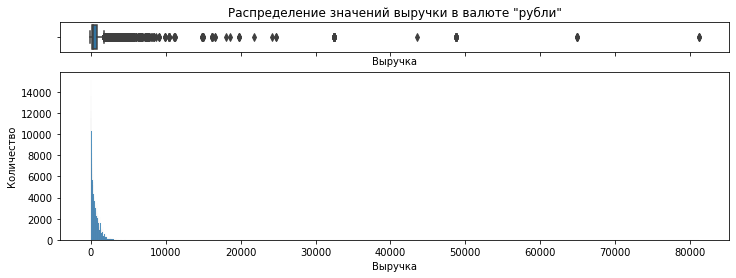

In [20]:
# Построим диаграмму размаха, чтобы проверить выбросы в поле 'revenue' для валюты "рубли"
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)}, figsize=(12, 4)
)

sns.boxplot(x=df[df["currency_code"] == "rub"]["revenue"], orient="h", ax=ax_box)
sns.histplot(data=df[df["currency_code"] == "rub"], x="revenue", ax=ax_hist)

ax_box.set(title='Распределение значений выручки в валюте "рубли"')
ax_box.set(xlabel="Выручка")
ax_hist.set(xlabel="Выручка")
ax_hist.set(ylabel="Количество")
plt.show()

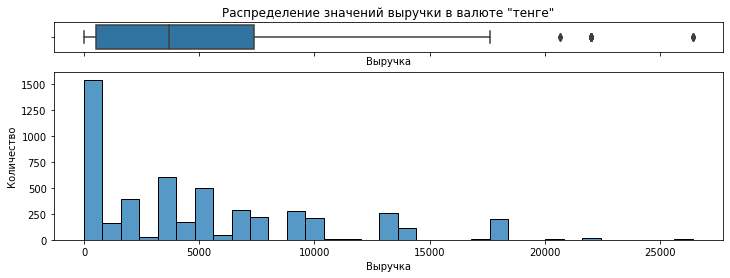

In [21]:
# Построим диаграмму размаха, чтобы проверить выбросы в поле 'revenue' для валюты "тенге"
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)}, figsize=(12, 4)
)

sns.boxplot(x=df[df["currency_code"] == "kzt"]["revenue"], orient="h", ax=ax_box)
sns.histplot(data=df[df["currency_code"] == "kzt"], x="revenue", ax=ax_hist)

ax_box.set(title='Распределение значений выручки в валюте "тенге"')
ax_box.set(xlabel="Выручка")
ax_hist.set(xlabel="Выручка")
ax_hist.set(ylabel="Количество")
plt.show()

По диаграммам размаха видно, что в поле 'revenue' есть аномально крупные значения, поэтому отфильтруем датафрейм по 99-процентилю и заменим аномально крупные значения на пропуски, чтобы не терять остальную информацию.

In [22]:
# Отберем значения выручки по 99-му процентилю
q99_rub = df.loc[df['currency_code'] == 'rub', 'revenue'].quantile(0.99)
q99_kzt = df.loc[df['currency_code'] == 'kzt', 'revenue'].quantile(0.99)
# Заменяем выбросы на NaN
condition = ((df['currency_code'] == 'rub') & (df['revenue'] > q99_rub)) | \
            ((df['currency_code'] == 'kzt') & (df['revenue'] > q99_kzt))
df.loc[condition, 'revenue'] = np.nan

In [23]:
empty_revenue = df["revenue"].isna().sum()
print(
    f"После фильтрации значений выручки по 99-процентилю аномально крупные значения " 
    f"заменены на пропуски в {empty_revenue} строках."
)

После фильтрации значений выручки по 99-процентилю аномально крупные значения заменены на пропуски в 2886 строках.


#### Проверка значений по полю 'tickets_count'

In [24]:
# Проверим статистические показатели по полю 'tickets_count' для валюты 'рубли'
df[df['currency_code']=='rub']['tickets_count'].describe()

count    285741.000000
mean          2.754078
std           1.171401
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

In [25]:
# Проверим статистические показатели по полю 'tickets_count' для валюты 'тенге'
df[df['currency_code']=='kzt']['tickets_count'].describe()

count    5068.000000
mean        2.763220
std         1.115393
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64

По полю 'tickets_count' распределения значений в рублях и тенге очень похожи, нулевых и отрицательных значений не обнаружено.

#### Анализ отрицательных значений выручки

In [26]:
negative_value = df[(df["revenue"] < 0) & (df["currency_code"] == "rub")][
    "order_id"
].count()
negative_value_share = (
    df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]["order_id"].count()
    / df[df["currency_code"] == "rub"]["order_id"].count()
    * 100
)
print(
    f"Количество заказов в рублях с отрицательным значением выручки: {negative_value}, "
    f"что составляет {round(negative_value_share,2)}% от общего количества заказов."
)

Количество заказов в рублях с отрицательным значением выручки: 381, что составляет 0.13% от общего количества заказов.


In [27]:
print("Распределение отрицательных значений выручки по типам устройств в абсолютном значении:")
print(
    df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]
    .groupby("device_type_canonical")["order_id"]
    .count()
)
print("Распределение отрицательных значений выручки по типам устройств в относительном значении:")
print(
    df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]
    .groupby("device_type_canonical")["order_id"]
    .count()
    / df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]["order_id"].count()
    * 100
)

Распределение отрицательных значений выручки по типам устройств в абсолютном значении:
device_type_canonical
desktop     23
mobile     358
Name: order_id, dtype: int64
Распределение отрицательных значений выручки по типам устройств в относительном значении:
device_type_canonical
desktop     6.036745
mobile     93.963255
Name: order_id, dtype: float64


In [28]:
print("Распределение отрицательных значений выручки по билетным партнерам в абсолютном значении:")
print(
    df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]
    .groupby("service_name")["order_id"]
    .count()
)
print("Распределение отрицательных значений выручки по билетным партнерам в относительном значении:")
print(
    df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]
    .groupby("service_name")["order_id"]
    .count()
    / df[(df["revenue"] < 0) & (df["currency_code"] == "rub")]["order_id"].count()
    * 100
)

Распределение отрицательных значений выручки по билетным партнерам в абсолютном значении:
service_name
Билеты без проблем    225
Билеты в руки          93
Лови билет!            36
Лучшие билеты          26
Тебе билет!             1
Name: order_id, dtype: int64
Распределение отрицательных значений выручки по билетным партнерам в относительном значении:
service_name
Билеты без проблем    59.055118
Билеты в руки         24.409449
Лови билет!            9.448819
Лучшие билеты          6.824147
Тебе билет!            0.262467
Name: order_id, dtype: float64


Большая часть отрицательных значений выручки в рублях обнаружена у мобильных устройств (93.97%) и у билетного партнера "Билеты без проблем" (59.06%). В перспективе следует выяснить природу этих значений, и если это технический сбой, проверить возможные неполадки в мобильной версии и у билетного оперетора "Билеты без проблем". В данном анализе мы не знаем причину появления таких значений, они составляют небольшой процент (0.13% от общего количества заказов), самое минимальное значение составляет -90.76, что не отразится на проведении анализа, поэтому принято решение оставить эти данные.

### Приведение выручки к единой валюте

In [29]:
# Выгружаем данные с информацией о курсе тенге к рублю
tenge_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

# # Приводим данные к типу datetime64
for column in ["created_dt_msk", "created_ts_msk"]:
    df[column] = pd.to_datetime(df[column])

tenge_df["data"] = pd.to_datetime(tenge_df["data"])

# Объединяем датафреймы
merged = df.merge(tenge_df, left_on="created_dt_msk", right_on="data", how="left")

# Применяем where для конвертации
merged["revenue_rub"] = merged["revenue"].where(
    merged["currency_code"] == "rub", merged["revenue"] * merged["curs"] / 100
)

# Удаляем ненужные столбцы
merged.drop(["data", "curs", "nominal", "cdx"], axis=1, inplace=True)
df = merged

### Создание новых столбцов

In [30]:
# Создаем новое поле с выручкой с продажи одного билета на мероприятие
df['one_ticket_revenue_rub'] = df['revenue_rub']/df['tickets_count']

# Создаем новое поле с номером месяца
df['month'] = df['created_dt_msk'].dt.month.astype('int')

# Создаем новое поле с разделением на сезоны
def seasons(row):
    if row['month'] in [1,2,12]:
        return 'зима'
    elif row['month'] in [3,4,5]:
        return 'весна'
    elif row['month'] in [6,7,8]:
        return 'лето'
    else:
        return 'осень'
df['season'] = df.apply(seasons, axis=1)

# Проверим, что столбцы созданы корректно
df[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head()

,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.94,380.4850,8,лето
1,289.45,144.7250,7,лето
2,1258.57,314.6425,10,осень
3,8.49,4.2450,7,лето
4,1390.41,463.4700,10,осень


### Смена типов данных

In [31]:
# Понижаем разрядность числовых данных
for column in ['order_id', 'event_id', 'age_limit', 'tickets_count',
               'event_id', 'month']:
    df[column] = pd.to_numeric(df[column], downcast='integer')

for column in ['revenue', 'total', 'revenue_rub', 'one_ticket_revenue_rub',
               'days_since_prev', 'city_id', 'venue_id']:
    df[column] = pd.to_numeric(df[column], downcast='float')

df[['age_limit', 'currency_code', 'device_type_canonical',
    'event_type_main']] = df[['age_limit', 'currency_code',
                              'device_type_canonical',
                              'event_type_main']].astype('category')

# Проверим корректность изменения типов данных
df.dtypes

order_id                           int32
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int32
cinema_circuit                    object
age_limit                       category
currency_code                   category
device_type_canonical           category
revenue                          float32
service_name                      object
tickets_count                       int8
total                            float32
days_since_prev                  float32
event_name                        object
event_type_description            object
event_type_main                 category
organizers                        object
region_name                       object
city_name                         object
city_id                          float32
venue_id                         float32
venue_name                        object
venue_address                     object
revenue_rub     

В столбцах created_dt_msk, created_ts_msk был изменен тип данных на datetime64.

В столбцах order_id, event_id, age_limit, tickets_count, revenue, total, event_id, city_id, venue_id, revenue_rub, one_ticket_revenue_rub, month, days_since_prev была понижена разрядность числовых типов данных. 

В категориальных столбцах age_limit, currency_code, device_type_canonical, event_type_main тип данных изменен на category.

Для дальнейшей работы были созданы новые столбцы: revenue_rub - поле с выручкой, приведенной к единой валюте - российскому рублю, one_ticket_revenue_rub - поле с выручкой с продажи одного билета на мероприятие, month - поле с номером месяца, season - поле с разделением на сезоны.

Обработанный датафрейм имеет 290809 строк, было отфильтровано 40 строк неполных дубликатов. В столбце revenue 2886 строк с аномально крупными значениями заменены на пропуски.

##  Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

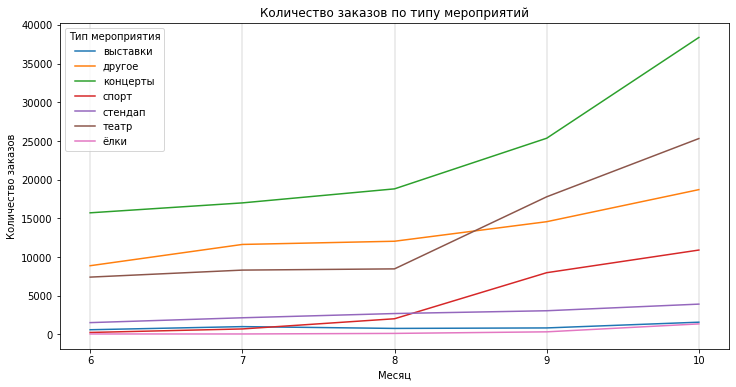

In [35]:
# Создаем сводную таблицу
pivot_event_type = pd.pivot_table(df, values='order_id', index='month', columns='event_type_main', aggfunc='count')

# Создаем график
ax = pivot_event_type.plot(kind='line', figsize=(12,6), rot=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Количество заказов по типу мероприятий')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.legend(title='Тип мероприятия')
plt.grid(axis='x', color='grey', linewidth=0.3)
plt.show()

Абсолютным лидером по количеству заказов являются концерты. Значительный сезонный рост наблюдается у спорта и ёлок, что объясняется началом спортивных сезонов и приближением новогодних праздников.Театр также демонстрирует устойчивый рост в осенние месяцы, выставки и стендап растут умеренно, оставаясь нишевыми категориями.

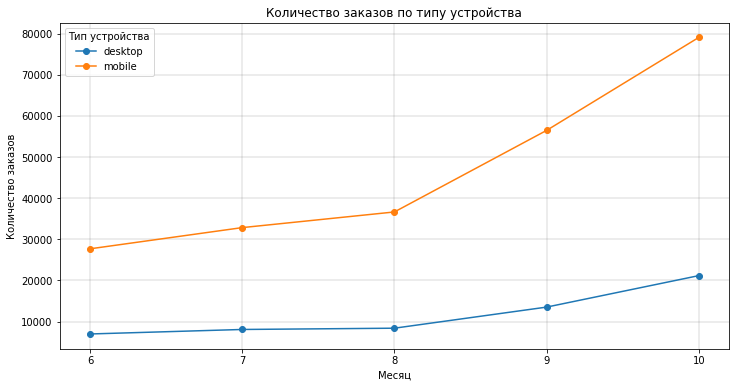

In [36]:
# Создаем сводную таблицу
pivot_device_type = pd.pivot_table(df, values='order_id', index='month', columns='device_type_canonical', aggfunc='count')

# Создаем график
ax = pivot_device_type.plot(kind='line', figsize=(12,6), rot=0, marker='o')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Количество заказов по типу устройства')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.legend(title='Тип устройства')
plt.grid(color='grey', linewidth=0.3)
plt.show()

Мобильные устройства доминируют над стационарными: заказов с мобильных в 3,5–4 раза больше в каждом месяце. Оба сегмента показывают рост от июня к октябрю, причём мобильный трафик растёт быстрее в абсолютных числах (+51,3 тыс. против +14,1 тыс.).

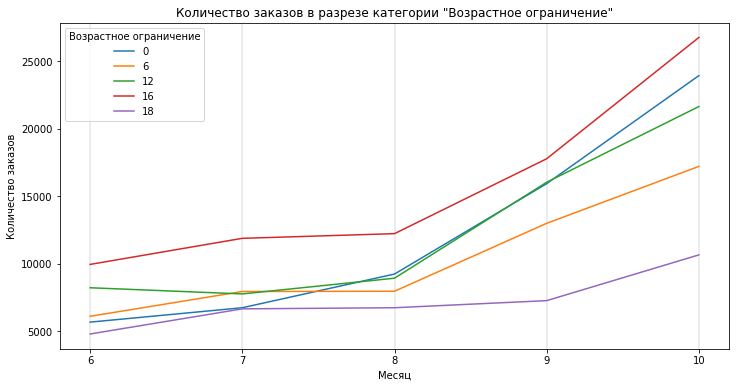

In [37]:
# Создаем сводную таблицу
pivot_age_limit = pd.pivot_table(df, values='order_id', index='month', columns='age_limit', aggfunc='count')

# Создаем график
ax = pivot_age_limit.plot(kind='line', figsize=(12,6), rot=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Количество заказов в разрезе категории "Возрастное ограничение"')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.legend(title='Возрастное ограничение')
plt.grid(axis='x', color='grey', linewidth=0.3)
plt.show()

Наибольший абсолютный рост демонстрируют категории 0+ и 16+ (более чем в 4 раза с июня по октябрь). Категория 18+ растёт медленнее остальных, что может указывать на меньшую сезонную волатильность взрослых мероприятий. Рост заказов в категориях 0+, 6+ осенью косвенно подтверждает увеличение доли семейного досуга.

In [38]:
# Создадим функцию для создания графиков
def plot_season_category_distribution(
    df,
    category: str,
    plot_title: str = "",
    legend_title: str = ""
):
    # Проверка наличия колонки
    if category not in df.columns:
        raise KeyError(
            f"Колонка '{category}' не найдена в DataFrame. "
            f"Доступные колонки: {list(df.columns)}"
        )

    # Группировка: уникальные заказы по сезону и выбранной категории
    grouped = df.groupby(['season', category])['order_id'].nunique().unstack(fill_value=0)

    # Приводим имена столбцов (категорий) к строковому типу
    grouped.columns = grouped.columns.astype(str)

    # Сортируем сезоны по общему числу заказов (по убыванию)
    grouped['total'] = grouped.sum(axis=1)
    grouped = grouped.sort_values(by='total')
    grouped_abs = grouped.drop('total', axis=1)

    # Вычисляем доли по строкам (нормировка на 100%)
    grouped_share = grouped_abs.div(grouped_abs.sum(axis=1), axis=0)

    # Построение графика
    ax = grouped_share.plot(kind='bar', figsize=(10,6), rot=0)

    # Добавление процентных подписей на каждый сегмент
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2.,
                height,
                f'{height*100:.1f}%',
                ha='center', va='bottom', fontsize=9
            )

    # Оформление
    plt.title(plot_title)
    plt.xlabel('Сезон')
    plt.ylabel('Доля')
    plt.legend(title=legend_title)
    plt.grid(axis='y', color='grey', linewidth=0.3)
    plt.tight_layout()
    plt.show()

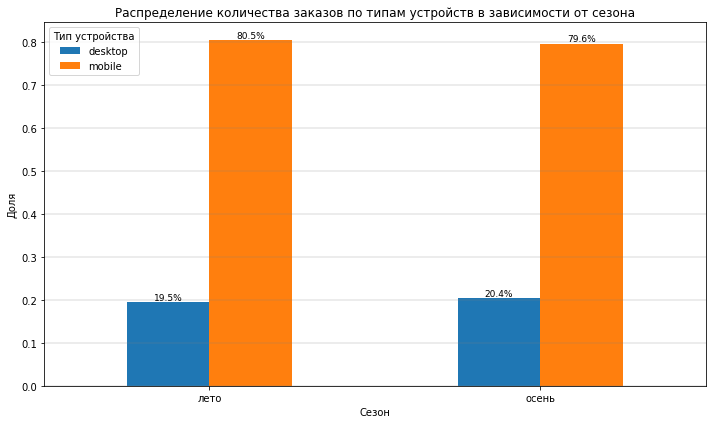

In [39]:
# Создадим график по типам устройств
plot_season_category_distribution(
    df=df,
    category='device_type_canonical',
    plot_title='Распределение количества заказов по типам устройств в зависимости от сезона',
    legend_title='Тип устройства'
)

Мобильные устройства абсолютно доминируют в оба сезона. Летом доля мобильных заказов немного выше (80,5% против 79,6%), что может объясняться сезоном отпусков и каникул — пользователи чаще покупают билеты «на ходу», находясь вне дома или офиса.

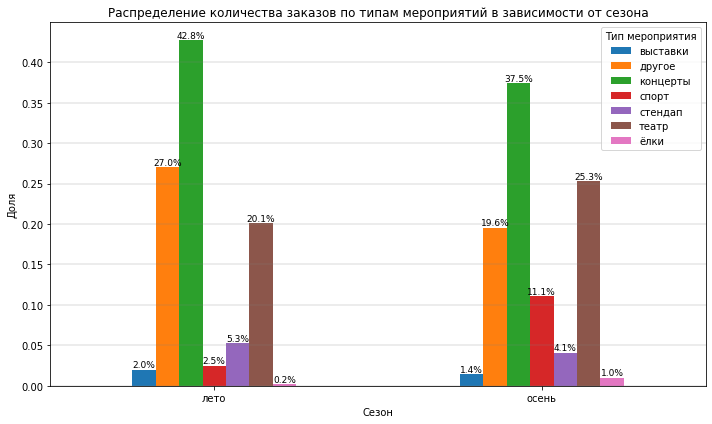

In [40]:
# Создадим график по типам мероприятий
plot_season_category_distribution(
    df=df,
    category='event_type_main',
    plot_title='Распределение количества заказов по типам мероприятий в зависимости от сезона',
    legend_title='Тип мероприятия'
)

Осенью резко возрастает интерес к спортивным событиям (старт сезонов в футболе, хоккее) и театральным премьерам (открытие сезона). Концерты сохраняют лидерство, и несмотря на снижение доли, концерты остаются самой востребованной категорией в оба периода. Наблюдается ранний спрос на Новый год, категория «Ёлки» показывает сильный рост доли осенью, что свидетельствует о начале планирования новогоднего досуга уже в сентябре-ноябре.

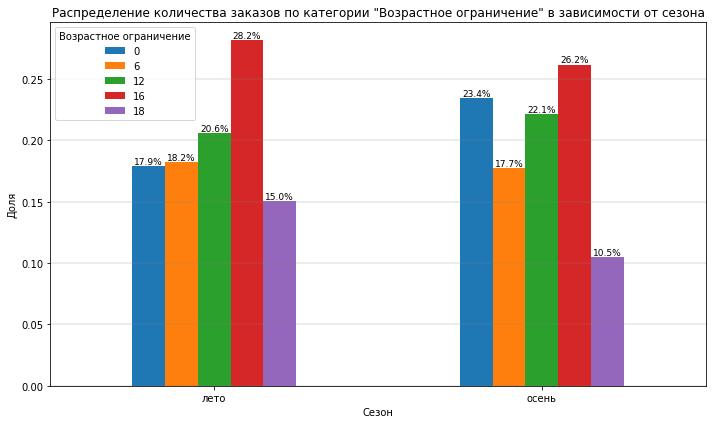

In [41]:
# Создадим график по возрастному ограничению
plot_season_category_distribution(
    df=df,
    category='age_limit',
    plot_title='Распределение количества заказов по категории "Возрастное ограничение" в зависимости от сезона',
    legend_title='Возрастное ограничение'
)

Значительный рост доли мероприятий 0+ (без возрастных ограничений) указывает на увеличение спроса на семейный досуг с началом учебного года. Наблюдается спад взрослого сегмента, падение доли 18+ на 4,5 п.п. связано с завершением сезона летних вечеринок и open-air фестивалей. Категория 16+ остается самой крупной, что подтверждает общий тренд платформы на молодежную аудиторию.

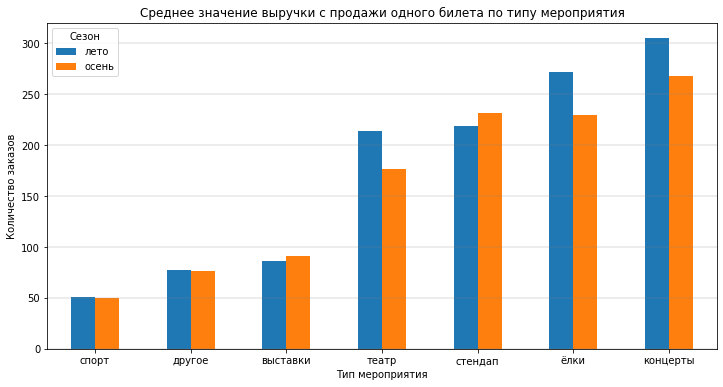

In [42]:
event_type_avg = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].agg('mean').unstack(fill_value=0)
event_type_avg['total'] = event_type_avg.sum(axis=1)
event_type_avg = event_type_avg.sort_values(by='total').drop('total', axis=1)

event_type_avg.plot(kind='bar', figsize=(12,6), rot=0)

plt.title('Среднее значение выручки с продажи одного билета по типу мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество заказов')
plt.legend(title='Сезон')
plt.grid(axis='y', color='grey', linewidth=0.3)
plt.show()

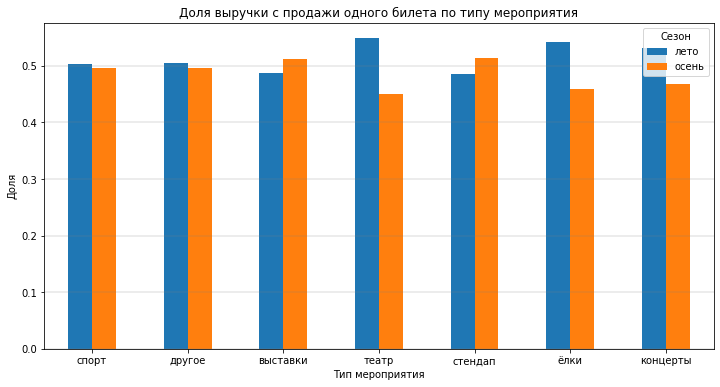

In [43]:
event_type_avg_share = event_type_avg.div(event_type_avg.sum(axis=1), axis=0)

event_type_avg_share.plot(kind='bar', figsize=(12,6), rot=0)
plt.title('Доля выручки с продажи одного билета по типу мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля')
plt.legend(title='Сезон')
plt.grid(axis='y', color='grey', linewidth=0.3)
plt.show()

У большинства типов мероприятий осенью наблюдается значительное снижение среднего значения выручки с продажи одного билета.
- Концерты: снижение на 12,1% (с 305 до 268 руб.);
- Театр: снижение на 17,8% (с 214 до 176 руб.);
- Ёлки: снижение на 15,1% (с 271 до 230 руб.).

Небольшой рост среднего чека зафиксирован у стендапа (+5,2%, с 219 до 231 руб.) и выставок (+5,5%, с 86 до 91 руб.).
Таким образом, рост количества заказов осенью сопровождается снижением средней доходности с одного билета в ключевых сегментах (концерты, театр, ёлки), что может быть связано с акционными предложениями, увеличением доли более дешёвых мест или изменением структуры спроса. Спорт и другое остаются низкомаржинальными категориями.

### Осенняя активность пользователей

In [44]:
# Создаем сводную таблицу
pivot = df[df["season"] == "осень"].pivot_table(
    values=["order_id", "user_id", "one_ticket_revenue_rub"],
    index="created_dt_msk",
    aggfunc={
        "order_id": "count",
        "user_id": "nunique",
        "one_ticket_revenue_rub": "mean",
    },
)
pivot["avg_orders_per_user"] = pivot["order_id"] / pivot["user_id"]
pivot.rename(
    columns={
        "order_id": "Количество заказов",
        "user_id": "DAU",
        "one_ticket_revenue_rub": "Средняя стоимость одного билета",
        "avg_orders_per_user": "Cреднее число заказов на пользователя",
    },
    inplace=True,
)
pivot

,Средняя стоимость одного билета,Количество заказов,DAU,Cреднее число заказов на пользователя
created_dt_msk,,,,
2024-09-01,200.168701,1348,569,2.369069
2024-09-02,189.464645,1391,580,2.398276
2024-09-03,80.130096,5124,783,6.544061
2024-09-04,177.685577,1785,688,2.594477
2024-09-05,189.510162,1960,745,2.630872
...,...,...,...,...
2024-10-27,186.968323,2865,1039,2.757459
2024-10-28,170.654938,2859,988,2.893725
2024-10-29,177.366074,2888,1005,2.873632


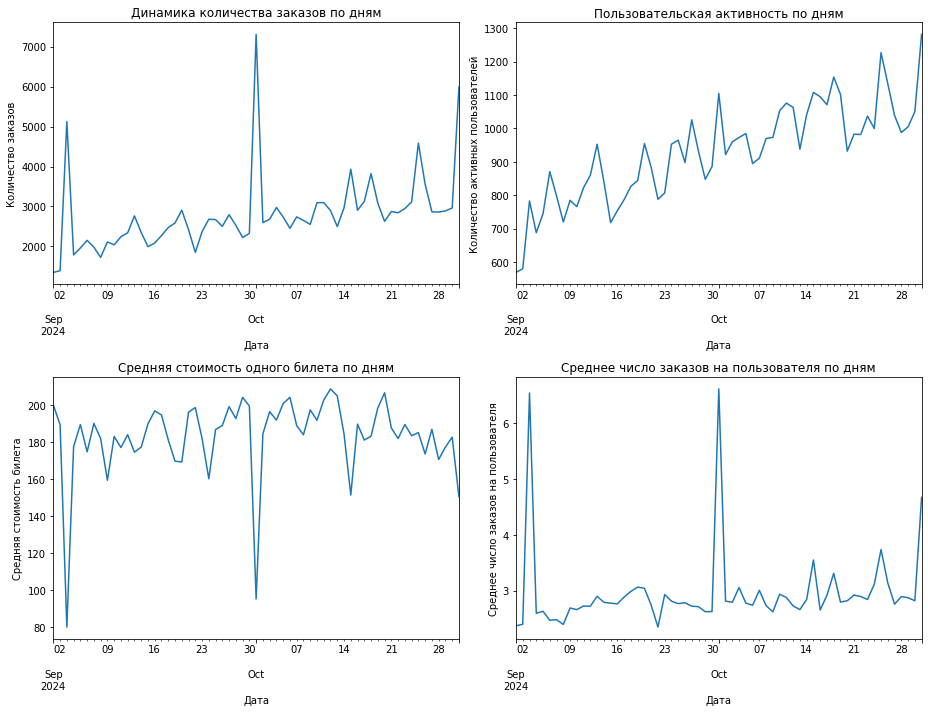

In [45]:
# Создаем графики по сводной таблице
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10))

pivot['Количество заказов'].plot(kind='line', ax=axes[0, 0])
axes[0, 0].set_title('Динамика количества заказов по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')

pivot['DAU'].plot(kind='line', ax=axes[0, 1])
axes[0, 1].set_title('Пользовательская активность по дням')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество активных пользователей')

pivot['Средняя стоимость одного билета'].plot(kind='line', ax=axes[1, 0])
axes[1, 0].set_title('Средняя стоимость одного билета по дням')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Средняя стоимость билета')

pivot['Cреднее число заказов на пользователя'].plot(kind='line', ax=axes[1, 1])
axes[1, 1].set_title('Среднее число заказов на пользователя по дням')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Среднее число заказов на пользователя')

plt.tight_layout()
plt.show()

Пик заказов 3 сентября и 1 октября — вероятно, старт продаж на новый сезон / акции / открытие предзаказов. Средний чек сильно колеблется: от 80 руб. (3 сентября) до 208 руб. (5 сентября). Это может быть связано с типом мероприятий (например, в дни с низким чеком много заказов категории «другое» или спорт). DAU (дневная аудитория) растёт с ~560 в начале сентября до ~1200+ в конце октября. Среднее число заказов на пользователя стабильно держится в диапазоне 2.5–3.5, с выбросами до 6.6 (1 октября), что говорит о высокой вовлечённости в пиковые дни.

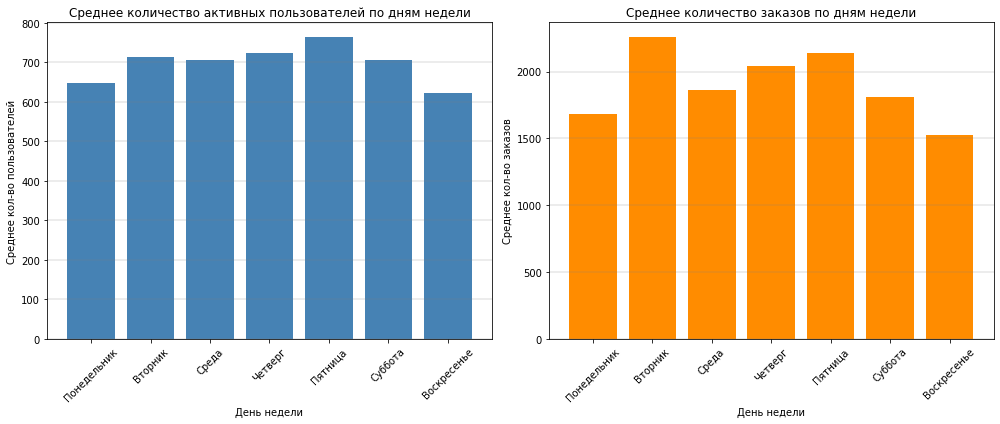

In [46]:
# Уникальные пользователи за каждый день
daily_users = (
    df.groupby(df['created_dt_msk'].dt.date)['user_id']
      .nunique()
      .reset_index(name='unique_users')
      .rename(columns={'created_dt_msk': 'date'})
)

# Количество заказов за каждый день (уникальные заказы)
daily_orders = (
    df.groupby(df['created_dt_msk'].dt.date)['order_id']
      .nunique()
      .reset_index(name='order_count')
      .rename(columns={'created_dt_msk': 'date'})
)

# Объединяем в одну таблицу
daily_stats = pd.merge(daily_users, daily_orders, on='date', how='outer').fillna(0)

# Преобразуем дату в datetime и добавляем день недели (0=Пн, 6=Вс)
daily_stats['date'] = pd.to_datetime(daily_stats['date'])
daily_stats['weekday'] = daily_stats['date'].dt.dayofweek

# Средние значения по дням недели
weekday_avg = daily_stats.groupby('weekday').agg({
    'unique_users': 'mean',
    'order_count': 'mean'
}).reset_index()

# Подготовка названий дней и порядка
day_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}
weekday_avg['day_name'] = weekday_avg['weekday'].map(day_names)

days_order = list(day_names.values())
weekday_avg['day_name'] = pd.Categorical(
    weekday_avg['day_name'], categories=days_order, ordered=True
)

weekday_avg = weekday_avg.sort_values('day_name')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График среднего количества пользователей
ax1.bar(weekday_avg['day_name'], weekday_avg['unique_users'], color='steelblue')
ax1.set_title('Среднее количество активных пользователей по дням недели')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Среднее кол-во пользователей')
ax1.grid(axis='y', color='grey', linewidth=0.3)
ax1.tick_params(axis='x', rotation=45)

# График среднего количества заказов
ax2.bar(weekday_avg['day_name'], weekday_avg['order_count'], color='darkorange')
ax2.set_title('Среднее количество заказов по дням недели')
ax2.set_xlabel('День недели')
ax2.set_ylabel('Среднее кол-во заказов')
ax2.grid(axis='y', color='grey', linewidth=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Вторник является абсолютным лидером по коммерческой эффективности. Несмотря на то, что трафик (число пользователей) немного ниже, чем в четверг или пятницу, именно во вторник посетители покупают в 1,3 раза чаще, чем в воскресенье. Это «день принятия решений о досуге».Период вторник–пятница генерирует основной объем продаж и высокий средний чек по количеству билетов в одни руки.

Воскресенье — наихудший день недели как по трафику (-18% к пятнице), так и по конверсии в заказы. Пользователи в воскресенье либо уже находятся на мероприятиях, либо отдыхают от экранов. Суббота показывает средний трафик, но низкую эффективность (2,57 заказа на чел.). Это говорит о том, что люди скорее мониторят варианты «на вечер», но покупают меньше билетов за раз. В понедельник аудитория минимальна. Пользователи возвращаются к рабочим задачам и меньше думают о развлечениях.

### Популярные события и партнёры

In [47]:
region_events = df.groupby('region_name')['event_id'].nunique()
region_orders = df['region_name'].value_counts(normalize=True)

df_regions = pd.DataFrame({
    'Количество событий': region_events,
    'Доля событий': region_events / region_events.sum(),
    'Количество заказов': df['region_name'].value_counts(),
    'Доля заказов': region_orders
})
df_regions.sort_values(by='Количество событий',ascending=False).head(10)

,Количество событий,Доля событий,Количество заказов,Доля заказов
Каменевский регион,5983,0.266777,91046,0.313335
Североярская область,3814,0.170063,44042,0.151571
Широковская область,1233,0.054978,16457,0.056637
Светополянский округ,1075,0.047933,7605,0.026173
Речиновская область,702,0.031302,6292,0.021654
Травяная область,683,0.030454,5045,0.017362
Горицветская область,551,0.024569,5165,0.017775
Серебринская область,542,0.024167,5610,0.019307
Яблоневская область,535,0.023855,6179,0.021265
Тепляковская область,530,0.023632,4387,0.015098


In [48]:
service_events = df.groupby('service_name')['event_id'].nunique()
service_orders = df['service_name'].value_counts(normalize=True)
service_revenue = df.groupby('service_name')['revenue_rub'].sum()

df_service = pd.DataFrame({
    'Количество событий': service_events,
    'Доля событий': service_events / service_events.sum(),
    'Количество заказов': df['service_name'].value_counts(),
    'Доля заказов': service_orders,
    'Суммарная выручка': service_revenue,
    'Доля от общей выручки': service_revenue/service_revenue.sum()   
})
df_service.sort_values(by='Количество событий',ascending=False).head(10)

,Количество событий,Доля событий,Количество заказов,Доля заказов,Суммарная выручка,Доля от общей выручки
Лови билет!,4884,0.199461,41120,0.141399,16668975.00,0.111790
Билеты без проблем,4263,0.174099,63693,0.219020,24255224.00,0.162667
Билеты в руки,3544,0.144736,40357,0.138775,13196266.00,0.088500
Облачко,2348,0.095892,26642,0.091613,18588614.00,0.124664
Лучшие билеты,1763,0.072000,17793,0.061184,2721491.00,0.018252
Мой билет,1310,0.053500,34839,0.119800,22042272.00,0.147826
Тебе билет!,1062,0.043372,5227,0.017974,2928882.75,0.019642
Прачечная,1027,0.041942,10273,0.035326,4746810.50,0.031834
Весь в билетах,867,0.035408,16848,0.057935,16493785.00,0.110615
Яблоко,716,0.029241,5039,0.017328,3868337.00,0.025943


Лидером по числу уникальных мероприятий является Каменевский регион (5 983 события), за ним с заметным отрывом следует Североярская область (3 814 событий). На эти два региона приходится 43,6% всех мероприятий и 46,4% всех заказов. Наблюдается сильная географическая концентрация. Рынок событий и спрос на билеты сосредоточены в двух ключевых регионах, в то время как остальные территории играют значительно меньшую роль.

Наиболее активные партнёры по охвату мероприятий: «Лови билет!», «Билеты без проблем» и «Билеты в руки» — суммарно обслуживают 52% всех мероприятий на платформе.

Наиболее активные партнеры по объёму заказов и выручке: «Билеты без проблем» — абсолютный лидер по количеству обработанных заказов (63 693, 21,9%) и общей выручке (24,3 млн руб., 16,3%). «Мой билет» демонстрирует высокую эффективность: имея лишь 5,3% мероприятий, партнёр генерирует 12% заказов и 14,8% выручки, что указывает на продажу более дорогих или более популярных билетов. «Весь в билетах» также выделяется высокой долей выручки (11,1%) при сравнительно скромном портфеле мероприятий (3,5%).

Концентрация заказов у билетных операторов ниже, чем в регионах: топ-5 партнёров контролируют 58,5% мероприятий и 63,4% заказов. Рынок диверсифицирован сильнее, присутствует несколько сильных игроков с разными стратегиями. «Лови билет!» и «Билеты в руки» работают с большим ассортиментом, но со средним чеком ниже среднего (их доля выручки меньше доли заказов). В то же время «Облачко», «Мой билет» и «Весь в билетах» ориентированы на более дорогой сегмент или имеют лучшую конверсию в покупки.

## Статистический анализ данных

In [49]:
# Отфильтруем данные только по осеннему сезону
test_df = df[df['season']=='осень']

In [50]:
# Проверяем наличие пересечений среди пользователей
user_a = test_df[test_df['device_type_canonical']=='mobile']['user_id']
user_b = test_df[test_df['device_type_canonical']=='desktop']['user_id']
intersection = list(set(user_a) & set(user_b))
print(len(intersection))

3274


In [51]:
# Отфильтруем пользователей, которые пользуются и мобильным, и стационарным устройствами, чтобы выборки были независимыми
test_df = test_df[~test_df['user_id'].isin(intersection)]
print(f'Объем данных для тестирования - {len(test_df)} строк.')

Объем данных для тестирования - 34697 строк.


In [52]:
# Проверяем разницу между тестовыми группами
users_a = test_df[test_df['device_type_canonical']=='mobile']['user_id'].nunique()
users_b = test_df[test_df['device_type_canonical']=='desktop']['user_id'].nunique()
print(f'Количество пользователей в группе А - {users_a}, количество пользователей в группе В - {users_b}.')
users_diff = (abs(users_a-users_b)/users_a)*100
print(f'Процентная разница между тестовыми группами составляет {round(users_diff,2)}%.')

Количество пользователей в группе А - 10967, количество пользователей в группе В - 1633.
Процентная разница между тестовыми группами составляет 85.11%.


In [53]:
# Посчитаем количество заказов на одного пользователя
orders_metric_a = test_df[test_df['device_type_canonical']=='mobile'].groupby('user_id')['order_id'].nunique()
orders_metric_b = test_df[test_df['device_type_canonical']=='desktop'].groupby('user_id')['order_id'].nunique()

In [54]:
# Проверим равенство дисперсий тестовой и контрольной групп

stat, p = levene(orders_metric_a, orders_metric_b, center='median') # 'median' устойчивее к выбросам
print(f'Статистика={stat:.3f}, p-value={p:.3f}')

if p > 0.05:
    print('Дисперсии равны (не отклоняем H0)')
else:
    print('Дисперсии различны (отклоняем H0)')

Статистика=79.204, p-value=0.000
Дисперсии различны (отклоняем H0)


Используем t-тест Уэлча, так как нужно сравнить средние значения двух независимых выборок, когда их дисперсии не равны, а размеры выборок отличаются.
В связи с несбалансированностью выборок (85/15) и ненормальным распределением исходных метрик, для проверки применимости t-критерия Уэлча проведём анализ распределения выборочного среднего для контрольной и тестовой групп. 

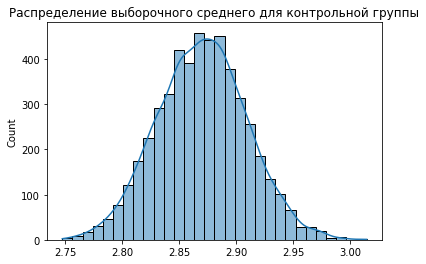

In [55]:
# Проверим распределение выборочного среднего
boot_means = [np.mean(np.random.choice(orders_metric_a, size=len(orders_metric_a), replace=True)) 
              for _ in range(5000)]

sns.histplot(boot_means, bins=30, kde=True)
plt.title('Распределение выборочного среднего для контрольной группы')
plt.show()

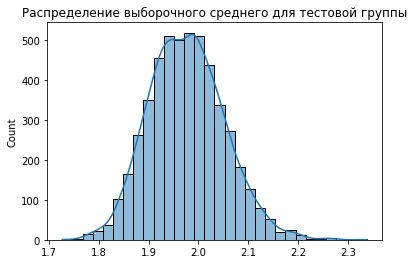

In [56]:
# Проверим распределение выборочного среднего
boot_means = [np.mean(np.random.choice(orders_metric_b, size=len(orders_metric_b), replace=True)) 
              for _ in range(5000)]

sns.histplot(boot_means, bins=30, kde=True)
plt.title('Распределение выборочного среднего для тестовой группы')
plt.show()

Гистограмма выборочных средних контрольной и тестовой групп демонстрирует приемлемую симметричность. Можем применить t-тест Уэлча. 

In [57]:
orders_metric_a.describe()

count    10967.000000
mean         2.869244
std          4.109043
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
Name: order_id, dtype: float64

In [58]:
orders_metric_b.describe()

count    1633.000000
mean        1.977955
std         3.062783
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        56.000000
Name: order_id, dtype: float64

При предварительной проверке статистических данных контрольной и тестовой групп видно, что среднее количество заказов на одного пользователя мобильного приложения больше по сравнению с пользователями стационарных устройств. Проведем t-тест Уэлча, используя одностороннюю проверку гипотезы с двумя выборками, чтобы проверить, что это различие статистически значимо.

Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя мобильного приложения меньше или равно количеству заказов на одного пользователя стационарного устройства.

Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения больше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

In [59]:
# Задаем уровень значимости
alpha = 0.05 

# Применяем t-тест Уэлча
stat_ttest, p_value_ttest = ttest_ind(
    orders_metric_a, 
    orders_metric_b, 
    equal_var=False, 
    alternative='greater'
) 

if p_value_ttest>alpha:
    print(f'p-value теста = {round(p_value_ttest, 4)}')
    print('Недостаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B равны.')
    print('Интерпретация: Среднее количество заказов на одного пользователя мобильного приложения ' 
          f'и пользователя стационарного устройства не отличается.')
else:
    print(f'p-value теста = {round(p_value_ttest, 4)}')
    print('Достаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B не равны, и в группе A больше.')
    print('Интерпретация: Среднее количество заказов на одного пользователя мобильного приложения '
          f'больше по сравнению с пользователями стационарных устройств.')

p-value теста = 0.0
Достаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B не равны, и в группе A больше.
Интерпретация: Среднее количество заказов на одного пользователя мобильного приложения больше по сравнению с пользователями стационарных устройств.


In [60]:
# Посчитаем время между заказами пользователей
days_metric_a = (
    test_df[
        (test_df["days_since_prev"] > 0)
        & (test_df["device_type_canonical"] == "mobile")
    ]
    .groupby("user_id")["days_since_prev"]
    .mean()
)
days_metric_b = (
    test_df[
        (test_df["days_since_prev"] > 0)
        & (test_df["device_type_canonical"] == "desktop")
    ]
    .groupby("user_id")["days_since_prev"]
    .mean()
)

In [61]:
# Проверим равенство дисперсий тестовой и контрольной групп

stat, p = levene(days_metric_a, days_metric_b, center='median') # 'median' устойчивее к выбросам
print(f'Статистика={stat:.3f}, p-value={p:.3f}')

if p > 0.05:
    print('Дисперсии равны (не отклоняем H0)')
else:
    print('Дисперсии различны (отклоняем H0)')

Статистика=34.836, p-value=0.000
Дисперсии различны (отклоняем H0)


Используем t-тест Уэлча, так как нужно сравнить средние значения двух независимых выборок, когда их дисперсии не равны, а размеры выборок отличаются.
В связи с несбалансированностью выборок (90/10) и ненормальным распределением исходных метрик, для проверки применимости t-критерия Уэлча проведём анализ распределения выборочного среднего для контрольной и тестовой групп. 

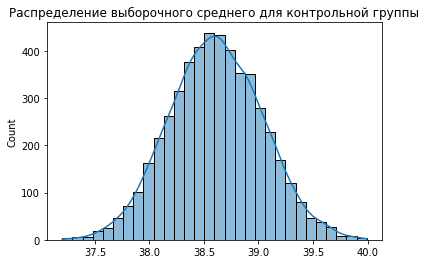

In [62]:
# Проверим распределение выборочного среднего
boot_means = [np.mean(np.random.choice(days_metric_a, size=len(days_metric_a), replace=True)) 
              for _ in range(5000)]

sns.histplot(boot_means, bins=30, kde=True)
plt.title('Распределение выборочного среднего для контрольной группы')
plt.show()

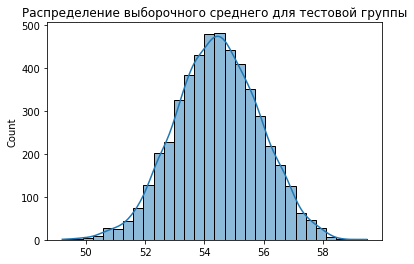

In [63]:
# Проверим распределение выборочного среднего
boot_means = [np.mean(np.random.choice(days_metric_b, size=len(days_metric_b), replace=True)) 
              for _ in range(5000)]

sns.histplot(boot_means, bins=30, kde=True)
plt.title('Распределение выборочного среднего для тестовой группы')
plt.show()

Гистограмма выборочных средних контрольной и тестовой групп демонстрирует приемлемую симметричность. Можем применить t-тест Уэлча.

In [64]:
days_metric_a.describe()

count    5762.000000
mean       38.616436
std        32.202408
min         1.000000
25%        14.000000
50%        28.500000
75%        56.000000
max       148.000000
Name: days_since_prev, dtype: float64

In [65]:
days_metric_b.describe()

count    619.000000
mean      54.443752
std       36.244678
min        1.000000
25%       25.000000
50%       49.000000
75%       81.000000
max      146.000000
Name: days_since_prev, dtype: float64

При предварительной проверке статистических данных контрольной и тестовой групп видно, что среднее время между заказами пользователей мобильных приложений меньше по сравнению с пользователями стационарных устройств. Проведем t-тест Уэлча, используя одностороннюю проверку гипотезы с двумя выборками, чтобы проверить, что это различие статистически значимо.

Нулевая гипотеза H₀: Среднее время между заказами пользователей мобильных приложений больше или равно среднему времени между заказами пользователей стационарных устройств.

Альтернативная гипотеза H₁: Среднее время между заказами пользователей мобильных приложений меньше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

In [66]:
# Зададим уровень значимости
alpha = 0.05 

# Проведем t-тест Уэлча
stat_ttest, p_value_ttest = ttest_ind(
    days_metric_a, 
    days_metric_b, 
    equal_var=False, 
    alternative='less'
) 

if p_value_ttest>alpha:
    print(f'p-value теста = {round(p_value_ttest, 4)}')
    print('Недостаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B равны.')
    print('Интерпретация: Среднее время между заказами пользователей мобильных приложений '
          f'и пользователей стационарных устройств не отличается.')
else:
    print(f'p-value теста = {round(p_value_ttest, 4)}')
    print('Достаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B не равны, и в группе A меньше.')
    print('Интерпретация: Среднее время между заказами пользователей мобильных приложений '
          f'меньше по сравнению с пользователями стационарных устройств.')

p-value теста = 0.0
Достаточно оснований, чтобы отклонить нулевую гипотезу. Выборочные средние в группах A и B не равны, и в группе A меньше.
Интерпретация: Среднее время между заказами пользователей мобильных приложений меньше по сравнению с пользователями стационарных устройств.


## Общий вывод и рекомендации

Анализ выполнен на основе объединённого датасета заказов и мероприятий сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 г. После предобработки и удаления аномалий объём составил 290809 записей о покупках билетов.

**Основные результаты анализа**

1. Востребованность мероприятий и сезонность
    
    Абсолютный лидер по числу заказов — концерты. Осенью наблюдается выраженный рост заказов на спорт и ёлки (более 80% заказов в этих категориях приходятся на осень), театр также демонстрирует устойчивый подъём. Концерты, стендап и выставки распределены по сезонам равномернее, но с небольшим осенним перевесом.


2. Средний чек
    
    Самый высокий средний чек — у концертов, однако осенью он заметно снижается. У стендапа и выставок средний чек осенью, напротив, немного растёт. Снижение чека в концертах и театре при одновременном росте числа заказов указывает на увеличение доли более доступных билетов или акционных предложений в пиковый сезон.
  
  
3. Пользовательская активность
    
    Мобильные устройства доминируют: заказов с них в 3,5–4 раза больше, чем со стационарных. Наибольшая активность пользователей приходится на четверг и пятницу, спад — на воскресенье и понедельник. Осенью DAU (дневная аудитория) вырастает почти вдвое — с ~560 в начале сентября до ~1100+ в конце октября. Пиковые дни продаж — 3 сентября и 1 октября (вероятно, старт продаж нового сезона или акции).
  
  
4. Регионы и партнёры — лидеры
    
    Рынок сильно сконцентрирован географически: Каменевский регион и Североярская область вместе дают 43,5% всех мероприятий и 46,4% заказов. Среди билетных операторов лидирует «Билеты без проблем» (21,9% заказов, 16,3% выручки). «Мой билет» и «Весь в билетах» показывают высокую эффективность: имея сравнительно небольшую долю мероприятий, они генерируют непропорционально большую выручку.

**Результаты проверки гипотез**

Проведённое A/B-тестирование (t-тест Уэлча) подтвердило статистически значимые различия в поведении пользователей мобильных и стационарных устройств:

- Среднее количество заказов на одного пользователя выше для мобильных устройств (2,86 против 1,97).
- Среднее время между заказами меньше для мобильных пользователей (38,5 дня против 54,0 дней).

Это свидетельствует о более высокой вовлечённости и частоте покупок у мобильной аудитории.

**Рекомендации**

1. Усилить развитие мобильного приложения.

      Мобильные пользователи активнее и совершают покупки чаще. Инвестиции в улучшение UX/UI мобильной версии, push-уведомления и персонализированные предложения могут дать наибольший прирост выручки.
      
      
2. Работать с ключевыми регионами.

      Учитывая высокую концентрацию спроса в двух регионах, целесообразно фокусировать маркетинговые усилия именно на них, а также анализировать причины слабой представленности в остальных регионах для возможного расширения.
      
      
3. Оптимизировать сотрудничество с билетными партнёрами.

      Выделить высокоэффективных партнёров («Мой билет», «Весь в билетах») для совместных акций и увеличения их доли на платформе. Для партнёров с большим ассортиментом, но низким средним чеком («Лови билет!», «Билеты в руки») рассмотреть механизмы повышения маржинальности (например, продвижение более дорогих категорий билетов).
      
      
4. Использовать сезонные пики.

      Планировать рекламные кампании и запуск специальных предложений под начало сентября и октября, когда наблюдается резкий всплеск заказов. Учитывать снижение среднего чека в пиковые периоды — возможно, внедрение динамического ценообразования или пакетных предложений для увеличения выручки с одного заказа.
      
      
5. Проанализировать природу отрицательных значений выручки.

      Хотя их доля мала (0,13%), почти 94% таких случаев приходится на мобильные устройства и конкретного партнёра. Стоит проверить возможные технические сбои или ошибки в оформлении возвратов, чтобы избежать потерь в будущем.